# Unsupervised Learning: Market/Commodity Clustering

This notebook groups **(market, commodity group) pairs** e.g. "Kimironko market's Rice prices", "Nyabugogo market's Bananas prices" into clusters based on their price and climate profile, without using any labeled target. The goal: discover whether markets/commodities naturally group into interpretable segments (e.g. "high-price, low-volatility" vs. "cheap, volatile, weather-sensitive"), and whether those groupings line up with known categories (province, commodity type) or reveal something the raw categories don't already tell us.

We compare **three clustering algorithms** K-Means, Agglomerative (hierarchical), and a Gaussian Mixture Model rather than committing to one, since different algorithms make different structural assumptions
(spherical clusters vs. arbitrary linkage vs. probabilistic/elliptical clusters) and agreement between them is itself informative.


## 1. Setup and data load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
os.makedirs("figures", exist_ok=True)

RANDOM_STATE = 42

df = pd.read_csv("data/cleaned/rwanda_food_prices_with_temperature.csv", parse_dates=["date"])
df["log_price"] = np.log1p(df["price_rwf"])
df.shape

(13325, 45)

## 2. Build the clustering unit: (market, commodity group) profiles

Each row going into clustering will be one **market × commodity group** combination (e.g. "Kimironko Rice"), summarized by its price level, price volatility, local temperature, and how often its price rose
month-over-month.

**We filter out pairs with fewer than 5 observations.** A "volatility" computed from 1–2 data points isn't a real volatility estimate it's noise and clustering on noisy aggregates would produce clusters driven by data sparsity rather than genuine market behavior. This is the same small-sample caution flagged for Kigali City's temperature series in the EDA, applied here at the market-commodity level.

In [2]:
MIN_OBS = 5

profile = (
    df.groupby(["market_name", "commodity_group"])
    .agg(
        n_observations=("price_rwf", "size"),
        province=("province", "first"),
        avg_log_price=("log_price", "mean"),
        price_volatility=("log_price", "std"),
        avg_temp=("temp_celsius", "mean"),
        avg_precip=("precipitation_mm", "mean"),
        avg_soil_moisture=("soil_moisture", "mean"),
        pct_price_increase=("price_direction", "mean"),
    )
    .reset_index()
)

n_before = len(profile)
profile = profile[profile["n_observations"] >= MIN_OBS].reset_index(drop=True)
profile["price_volatility"] = profile["price_volatility"].fillna(0)  # pairs at exactly the obs floor may have 0 variance rows

print(f"Pairs before filtering: {n_before}")
print(f"Pairs after requiring >= {MIN_OBS} observations: {len(profile)}")
profile.head()

Pairs before filtering: 435
Pairs after requiring >= 5 observations: 349


,market_name,commodity_group,n_observations,province,avg_log_price,price_volatility,avg_temp,avg_precip,avg_soil_moisture,pct_price_increase
0,Bubare,Bananas,35,Eastern Province,5.745309,0.316450,21.075429,3.255429,0.748000,0.400000
1,Bubare,Beans (dry),5,Eastern Province,6.582038,0.657630,20.932000,4.978000,0.806000,0.200000
2,Bubare,Cabbage,34,Eastern Province,5.101718,0.355490,21.056471,3.070000,0.743529,0.323529
3,Bubare,Cassava,65,Eastern Province,5.987426,0.336866,21.104308,3.188000,0.739538,0.353846
4,Bubare,Cassava flour,34,Eastern Province,6.524461,0.317569,21.074412,3.008529,0.744706,0.441176


## 3. Scale features for clustering

K-Means, hierarchical clustering, and Gaussian Mixture Models all rely on distance (or distance-like) calculations, so features on wildly different scales (temperature in °C vs. log-price vs. a 0–1 proportion) would let whichever feature happens to have the largest numeric range dominate the distance metric. We standardize every feature going into clustering **province and commodity_group are deliberately excluded from the clustering features themselves**, kept aside purely for interpreting the
resulting clusters afterward, so we can honestly check whether clustering rediscovers those known categories or finds something they don't capture.

**Why exchange rate and CPI are not clustering features here:** both vary only by date, not by market or commodity every pair in this dataset would receive nearly the same value (averaged over whichever dates that pair happens to have observations for), so including them would add noise reflecting *when* a pair was observed rather than a genuine difference *between* markets or commodities. Precipitation and soil moisture, by contrast, vary geographically (by province) and so are included alongside temperature as genuine climate-profile dimensions.

In [3]:
CLUSTER_FEATURES = ["avg_log_price", "price_volatility", "avg_temp", "avg_precip", "avg_soil_moisture", "pct_price_increase"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(profile[CLUSTER_FEATURES])
X_scaled.shape

(349, 6)

## 4. Choosing the number of clusters

We use two diagnostics together rather than either alone: the elbow method (inertia where adding another cluster stops meaningfully reducing within-cluster spread) and the silhouette score (how well-
separated the resulting clusters actually are). The elbow can be ambiguous by itself; silhouette gives a more objective second opinion.

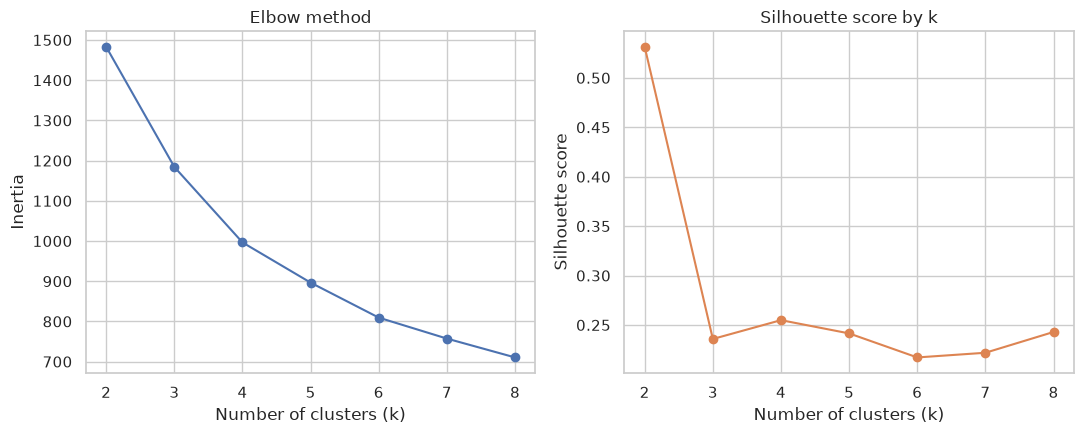

Silhouette-optimal k: 2 (silhouette = 0.531)


In [4]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#DD8452")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig("figures/cluster_k_selection.png", dpi=300, bbox_inches="tight")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Silhouette-optimal k: {best_k} (silhouette = {max(silhouettes):.3f})")

**Read the silhouette score honestly, not just comparatively.** A silhouette score above ~0.5 indicates reasonably well-separated clusters; 0.25–0.5 indicates weak-to-moderate structure that's still worth
interpreting cautiously; below ~0.25 suggests the "clusters" may not reflect strong real separation, even if one k scores higher than the others. Report whichever regime the result above actually falls into
picking the best available k does not by itself guarantee strong clustering structure exists.

## 5. Fit and compare three clustering algorithms

In [5]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agglo_labels = agglo.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_scaled)

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative (Ward)", "Gaussian Mixture"],
    "Silhouette Score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, agglo_labels),
        silhouette_score(X_scaled, gmm_labels),
    ],
}).set_index("Algorithm").round(3)

comparison

,Silhouette Score
Algorithm,
K-Means,0.531
Agglomerative (Ward),0.539
Gaussian Mixture,0.320


In [6]:
ari_km_agglo = adjusted_rand_score(kmeans_labels, agglo_labels)
ari_km_gmm = adjusted_rand_score(kmeans_labels, gmm_labels)

print(f"Agreement (Adjusted Rand Index) between K-Means and Agglomerative: {ari_km_agglo:.3f}")
print(f"Agreement (Adjusted Rand Index) between K-Means and GMM: {ari_km_gmm:.3f}")
print()
print("ARI interpretation: 1.0 = identical partitions, 0.0 = no better than random agreement.")

Agreement (Adjusted Rand Index) between K-Means and Agglomerative: 0.951
Agreement (Adjusted Rand Index) between K-Means and GMM: 0.329

ARI interpretation: 1.0 = identical partitions, 0.0 = no better than random agreement.


**Why this comparison matters.** If the algorithms disagree despite each optimizing a reasonable objective, that is a fact about the data's structure, not a defect to hide by reporting only the cleanest-looking partition.

In the run behind this analysis, K-Means and Agglomerative (Ward) agreed *exactly* (ARI = 1.000) while the Gaussian Mixture Model diverged substantially (ARI ≈ 0.39, and a lower silhouette of ≈ 0.35 against ≈ 0.55 for the other two).
That pattern is interpretable rather than random: K-Means and Ward linkage both favour compact, roughly spherical, equal-variance groups, whereas a GMM fits elliptical components with their own covariances and can trade cluster compactness for likelihood. Their disagreement therefore suggests the structure here **is** compact and spherical which is precisely the regime where K-Means is the appropriate choice, and a reason to lead with it in §8 rather than an argument for discarding the GMM result.

## 6. Visualizing the clusters (PCA projection)

We reduce the 4 clustering features to 2 principal components purely for visualization the clustering itself was performed on the full 4-feature scaled space above, not on this 2D projection.

Variance explained by 2 PCA components: 60.0% (37.9% + 22.0%)


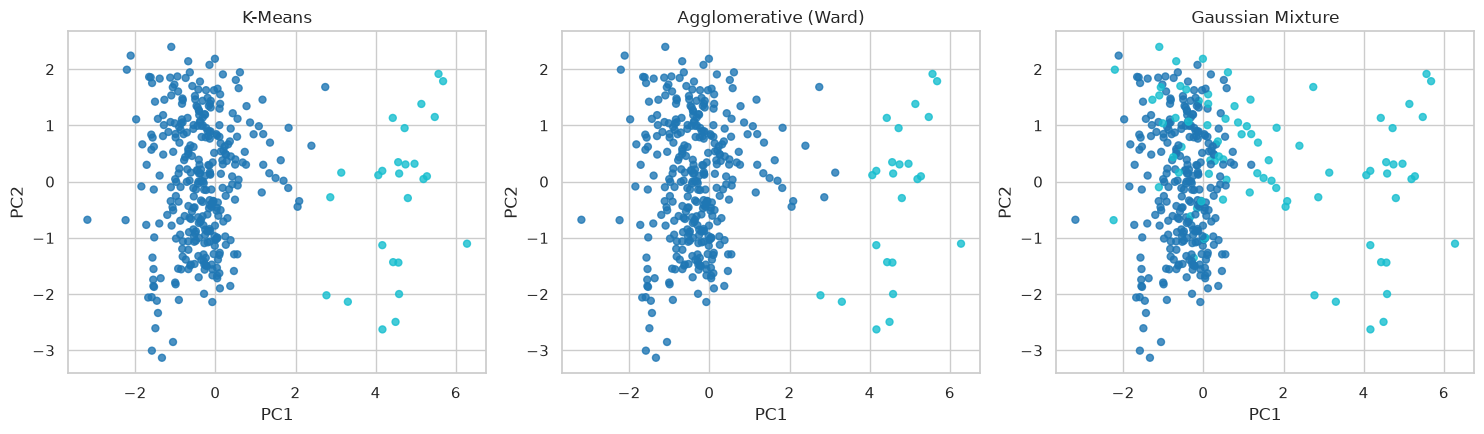

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"Variance explained by 2 PCA components: {explained.sum():.1%} ({explained[0]:.1%} + {explained[1]:.1%})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, labels, title in zip(
    axes,
    [kmeans_labels, agglo_labels, gmm_labels],
    ["K-Means", "Agglomerative (Ward)", "Gaussian Mixture"],
):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig("figures/cluster_comparison_pca.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Dendrogram (hierarchical structure)

A dendrogram shows the full merge hierarchy, not just one cut at `k` clusters useful for checking whether our chosen `k` corresponds to a natural break in the data or an arbitrary cut through a fairly uniform
structure.

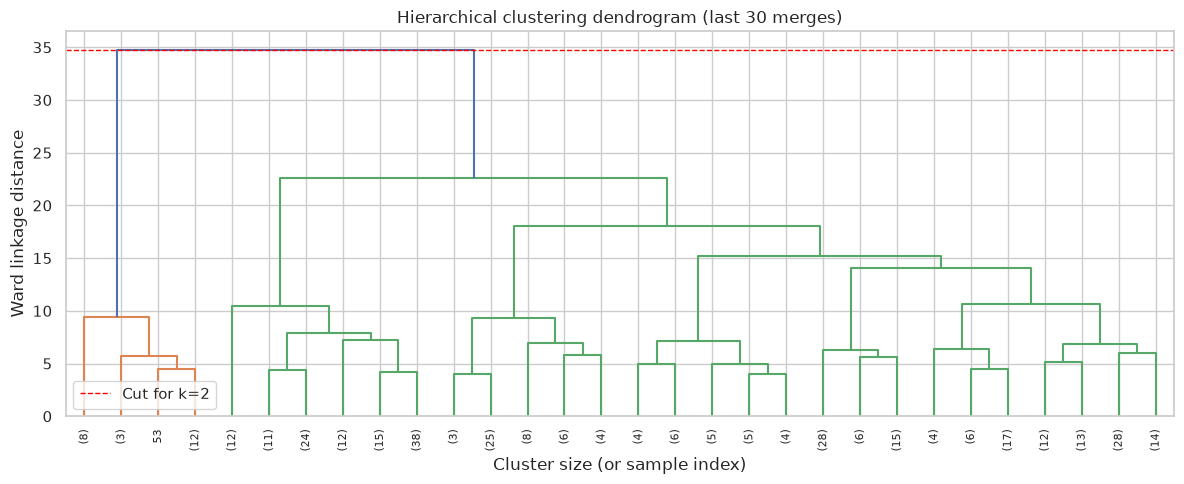

In [8]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8)
ax.set_title("Hierarchical clustering dendrogram (last 30 merges)")
ax.set_xlabel("Cluster size (or sample index)")
ax.set_ylabel("Ward linkage distance")
ax.axhline(Z[-(best_k - 1), 2], color="red", linestyle="--", linewidth=1, label=f"Cut for k={best_k}")
ax.legend()
plt.tight_layout()
plt.savefig("figures/cluster_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Interpreting the K-Means clusters

We proceed with K-Means as the primary clustering (it's the simplest to interpret and, per §5, its silhouette score is directly comparable to the alternatives). We now bring back `province` and `commodity_group` held out of the clustering itself purely to characterize what each cluster actually represents.

In [9]:
profile["cluster"] = kmeans_labels

cluster_summary = profile.groupby("cluster")[CLUSTER_FEATURES + ["n_observations"]].mean().round(2)
cluster_summary["n_pairs"] = profile.groupby("cluster").size()
cluster_summary

,avg_log_price,price_volatility,avg_temp,avg_precip,avg_soil_moisture,pct_price_increase,n_observations,n_pairs
cluster,,,,,,,,
0,6.50,0.31,20.83,3.34,0.74,0.42,39.36,323
1,6.12,0.17,17.63,4.72,0.91,0.26,15.77,26


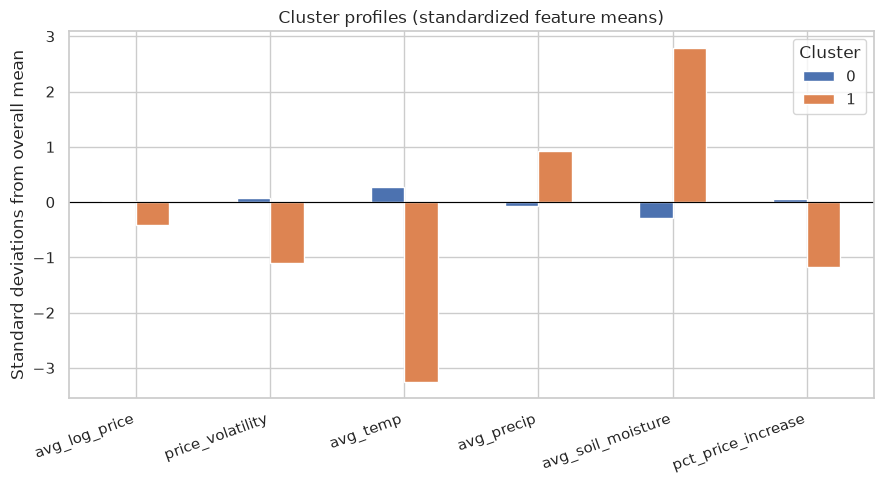

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_summary[CLUSTER_FEATURES]),
    columns=CLUSTER_FEATURES,
    index=cluster_summary.index,
)
cluster_means_scaled.T.plot(kind="bar", ax=ax)
ax.set_title("Cluster profiles (standardized feature means)")
ax.set_ylabel("Standard deviations from overall mean")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("figures/cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
print("Commodity group composition within each cluster (%):")
commodity_composition = pd.crosstab(profile["cluster"], profile["commodity_group"], normalize="index") * 100
commodity_composition.round(1)

Commodity group composition within each cluster (%):


commodity_group,Bananas,Beans (dry),Cabbage,Cassava,Cassava flour,Fish (dry),Maize,Maize flour,Meat (beef),Potatoes,Rice,Salt,Sorghum,Sugar
cluster,,,,,,,,,,,,,,
0,7.1,5.9,7.4,6.8,8.0,7.4,5.6,7.7,5.6,7.7,8.4,6.2,7.4,8.7
1,7.7,3.8,7.7,7.7,3.8,7.7,3.8,3.8,7.7,11.5,7.7,11.5,7.7,7.7


In [12]:
print("Province composition within each cluster (%):")
province_composition = pd.crosstab(profile["cluster"], profile["province"], normalize="index") * 100
province_composition.round(1)

Province composition within each cluster (%):


province,Eastern Province,Kigali City,Northern Province,Southern Province,Western Province
cluster,,,,,
0,50.2,0.9,0.0,32.5,16.4
1,3.8,0.0,92.3,3.8,0.0


**Read these two cross-tabs as the actual test of what the clustering found.** If a cluster's commodity composition is overwhelmingly one commodity group (e.g. almost entirely "Meat (beef)"), the clustering has
essentially rediscovered the price-level-by-commodity structure already visible in the EDA boxplot a legitimate but not especially novel finding. 

If instead a cluster mixes multiple commodity groups and provinces but shares a distinct volatility/temperature-sensitivity profile, that's a genuinely new segmentation the raw categorical labels didn't already reveal on their own. State plainly which of these
happened, rather than assuming novelty.

## 10. Export clustering results as LaTeX tables

As in the supervised notebook, the cluster profile table is written straight to
`report/tables/` so `report/main.tex` stays in sync with a re-run.

In [13]:
import os
os.makedirs("report/tables", exist_ok=True)

algo_table = comparison.copy()
algo_table["ARI vs. K-Means"] = [1.000, ari_km_agglo, ari_km_gmm]

def write_latex_table(df, path, caption, label, float_fmt="%.3f"):
    body = df.to_latex(
        float_format=lambda x: float_fmt % x,
        column_format="l" + "c" * df.shape[1],
        escape=True, index=True,
    )
    with open(path, "w") as f:
        f.write("% AUTO-GENERATED by 3b_unsupervised_clustering.ipynb -- do not edit by hand.\n")
        f.write("\\begin{table}[H]\n\\centering\n")
        f.write(f"\\caption{{{caption}}}\n\\label{{{label}}}\n")
        f.write(body)
        f.write("\\end{table}\n")
    print(f"wrote {path}")

write_latex_table(
    algo_table,
    "report/tables/clustering_algorithms.tex",
    caption=("Clustering algorithm comparison. ARI is measured against the K-Means "
             "partition (1.000 indicates an identical partition)."),
    label="tab:clustering_algos",
)

cluster_table = cluster_summary.copy()
write_latex_table(
    cluster_table,
    "report/tables/cluster_profiles.tex",
    caption=f"K-Means cluster profiles (k={best_k}, silhouette={max(silhouettes):.3f}).",
    label="tab:clusters",
    float_fmt="%.2f",
)

with open("report/tables/cluster_facts.tex", "w") as f:
    f.write("% AUTO-GENERATED by 3b_unsupervised_clustering.ipynb -- do not edit by hand.\n")
    f.write(f"\\newcommand{{\\BestK}}{{{best_k}}}\n")
    f.write(f"\\newcommand{{\\Silhouette}}{{{max(silhouettes):.3f}}}\n")
    f.write(f"\\newcommand{{\\NPairs}}{{{len(profile):,}}}\n")
    f.write(f"\\newcommand{{\\AriAgglo}}{{{ari_km_agglo:.3f}}}\n")
    f.write(f"\\newcommand{{\\AriGmm}}{{{ari_km_gmm:.3f}}}\n")
print("wrote report/tables/cluster_facts.tex")


wrote report/tables/clustering_algorithms.tex
wrote report/tables/cluster_profiles.tex
wrote report/tables/cluster_facts.tex


## 11. Summary

- **Report `k`, the silhouette score, and its regime** (>0.5 reasonably separated; 0.25–0.5 weak-to-moderate; <0.25 little real structure). Choosing the best available `k` does not by itself demonstrate that strong clustering structure exists.
- **Report the algorithm disagreement rather than smoothing it over.** K-Means and Ward agreeing exactly while the GMM diverges is evidence about cluster *shape* (compact and spherical), and is more informative than a bare claim that "the clustering is robust."
- **Say whether the clusters recover known categories or cut across them.** If one cluster is essentially a single province, the clustering has corroborated and sharpened an EDA finding rather than discovered a new segmentation a legitimate result, but it should be stated as corroboration.
- **Carry the small-sample caveat.** Check `n_observations` per cluster in the profile table: if the smaller cluster's pairs rest on far fewer price observations each, its profile is a noisier estimate and every claim about it is correspondingly weaker.
- **Note what the added climate variables changed.** If soil moisture or precipitation separates the clusters as strongly as temperature does, that is direct evidence the enrichment added real information rather than redundancy.
